# SMET input initialization

Taking the base smet files associated with the buoy an input the seasonal change in temperature from the CMIP6 projections with an associated sensitivity parameter applied to the precipitation sum. 

## Precipitation change function and Plot

Estimates the change in precipitation based on Seasonal temperature increase.
    
Returns: New precipitation amount after warming (float).


The following fields do not conform to the SMET standard: ['OSWR', 'GEO_HEAT', 'TS1', 'TS2', 'TS3']


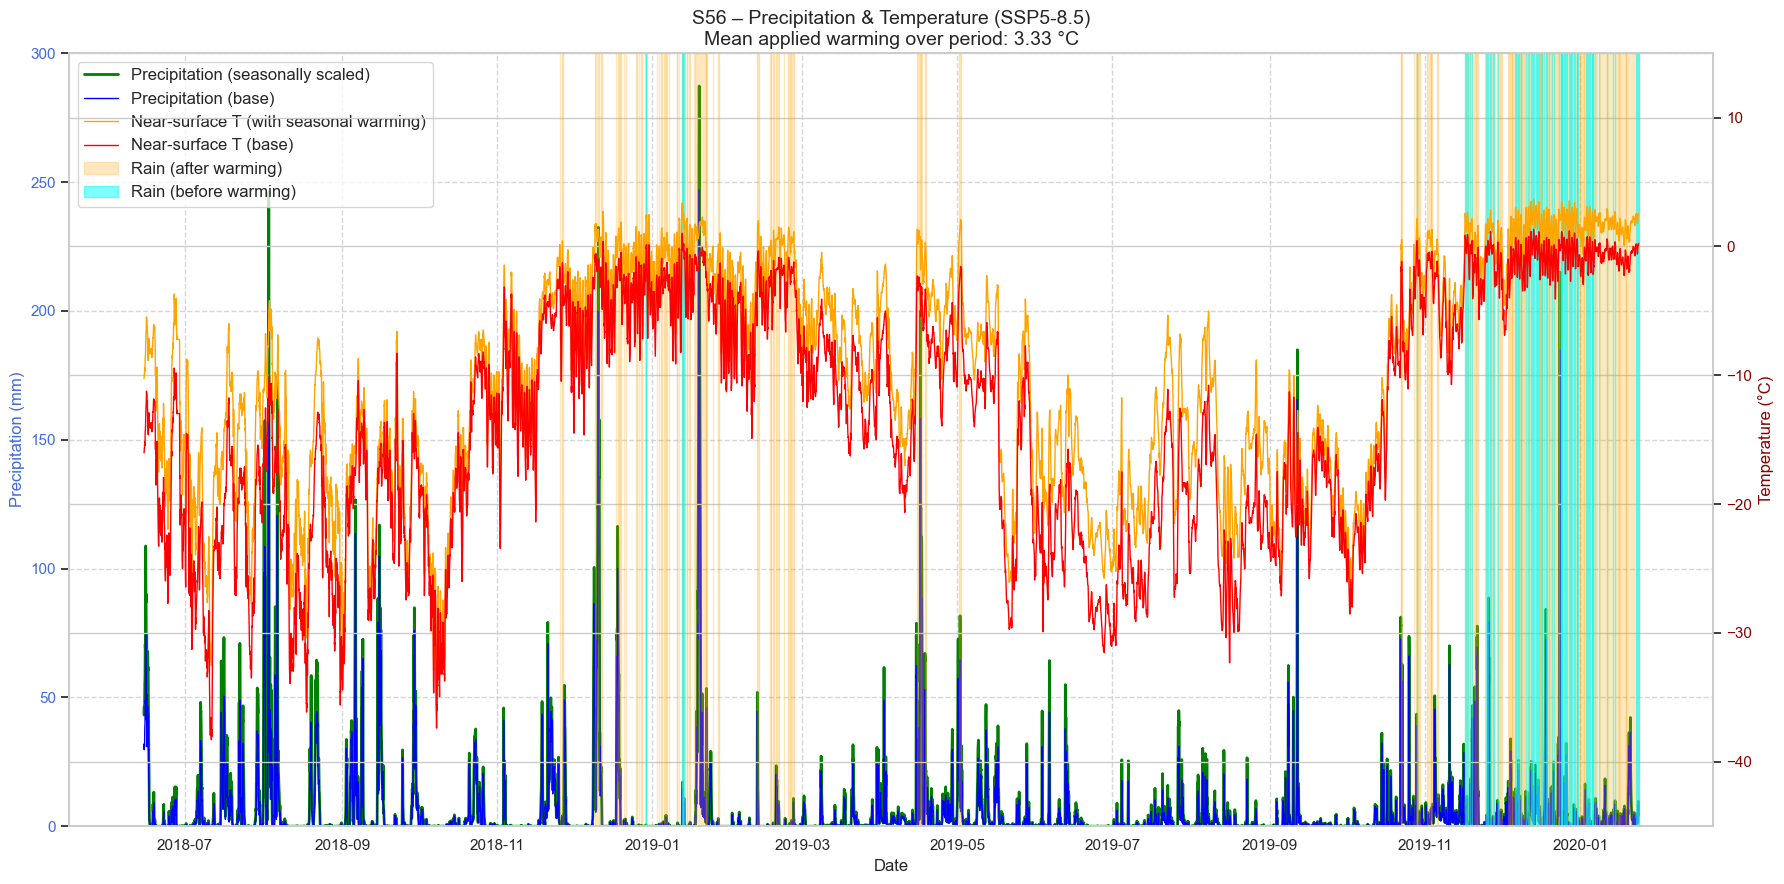

In [38]:
import snowpat.pysmet as smet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

file = smet.read('\S56\S56_OHF_5_TAera5.smet')

# Start from pandas data
df = file.data.copy()

# Ensure timestamp column is datetime (rename if yours differs)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Month→season map
_MONTH_TO_SEASON = {
    12:'DJF', 1:'DJF', 2:'DJF',
     3:'MAM', 4:'MAM', 5:'MAM',
     6:'JJA', 7:'JJA', 8:'JJA',
     9:'SON',10:'SON',11:'SON'
}

# Season warming (°C) 
season_warming = {'DJF':2.342, 'MAM':3.632, 'JJA':5.759, 'SON':1.705}
sensitivity=0.0667

def precipitation_change_seasonal(
    df: pd.DataFrame,
    season_warming: dict,
    sensitivity=sensitivity,
    ts_col='timestamp',
    base_col='PSUM',
    out_col='new_precip'
):
    ts = pd.to_datetime(df[ts_col], errors='coerce')
    season = ts.dt.month.map(_MONTH_TO_SEASON)

    # Per-row warming
    warm_series = season.map(season_warming)

    # Sensitivity can be scalar or dict per season
    if isinstance(sensitivity, dict):
        sens_series = season.map(sensitivity)
    else:
        sens_series = pd.Series(sensitivity, index=df.index)

    # Exponential factor and new precip
    factor = (1 + sens_series) ** warm_series
    base = df[base_col].clip(lower=0)

    out = df.copy()
    out['season'] = season
    out['warming_applied'] = warm_series
    out['precip_factor'] = factor
    out[out_col] = base * factor
    return out

# # Apply seasonal scaling
df = precipitation_change_seasonal(df, season_warming, sensitivity)

# Slice the analysis period
mask = (df['timestamp'] >= '2018-06-15') & (df['timestamp'] <= '2020-01-24')
df_slice = df.loc[mask].reset_index(drop=True)

# Base & new precip
base_precip = df_slice['PSUM']
new_precip  = df_slice['new_precip']

# Temperatures (K → °C)
TS = df_slice['TA'] - 273.15
TS_warmed = TS + df_slice['warming_applied']  # per-row seasonal warming

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(18, 6))

# Precipitation time series
ax1.plot(df_slice['timestamp'], new_precip, '-', color='green', lw=2,
         label='Precipitation (seasonally scaled)')
ax1.plot(df_slice['timestamp'], base_precip, '-', color='blue', lw=1,
         label='Precipitation (base)')
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Precipitation (mm)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, linestyle='--', alpha=0.8)
ax1.set_ylim(0, 300)

# Temperature axis
ax2 = ax1.twinx()
ax2.plot(df_slice['timestamp'], TS_warmed, '-', color='orange', lw=1,
         label='Near-surface T (with seasonal warming)')
ax2.plot(df_slice['timestamp'], TS, '-', color='red', lw=1,
         label='Near-surface T (base)')
ax2.set_ylabel('Temperature (°C)', color='darkred', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkred')
ax2.set_ylim(-45, 15)


# Highlight where it's raining after warming (precip >0 and T_warmed >0°C)
is_rain_before = (base_precip > 0 ) & (TS > 0)
is_rain_after = (new_precip > 0) & (TS_warmed > 0)
ax2.fill_between(
    df_slice['timestamp'], ax2.get_ylim()[0], ax2.get_ylim()[1],
    where=is_rain_after, alpha=0.25, color = 'orange', label='Rain (after warming)'
)
ax2.fill_between(
    df_slice['timestamp'], ax2.get_ylim()[0], ax2.get_ylim()[1],
    where=is_rain_before, alpha=0.5, color = 'cyan', label='Rain (before warming)'
)

# Title & legend
avg_warm = df_slice['warming_applied'].mean()
plt.title(f"{file.meta_data.station_id} – Precipitation & Temperature (SSP5-8.5)\n"
          f"Mean applied warming over period: {avg_warm:.2f} °C", fontsize=14)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=12, frameon=True)

plt.tight_layout()
plt.show()

## Overwrite the new temperature and preciptation change and save to different file

In [39]:
# 1) Ensure datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# 2) Build per-row seasonal warming WITHOUT adding columns
season = df['timestamp'].dt.month.map(_MONTH_TO_SEASON)
warming_applied = season.map(season_warming)  # Series aligned to df

# 3) Overwrite TA (K) and PSUM (mm)
df.loc[:, 'TA']   = df['TA'] + warming_applied
df.loc[:, 'PSUM'] = df['PSUM'] * ((1 + sensitivity) ** warming_applied)

# 4) If earlier code added helper columns, remove them
df.drop(columns=['season', 'warming_applied', 'precip_factor', 'new_precip'],
        inplace=True, errors='ignore')

# 5) Write out (use a new filename to preserve the original)
file.setData(df)
file.write("S56_OHF_5_TAera5_SSP585_Seasonal.smet")
file.info()

Using fields:  ['timestamp', 'TA', 'RH', 'TSG', 'TSS', 'HS', 'VW', 'DW', 'OSWR', 'ISWR', 'ILWR', 'PSUM', 'GEO_HEAT', 'TS1', 'TS2', 'TS3']
SMETFile:
MetaData:
Station ID: S56
Location: (Latitude: -70.582, Longitude: -7.944, Altitude: 0.0, EPSG: 21781)
No Data: -999.0
Fields: ['timestamp', 'TA', 'RH', 'TSG', 'TSS', 'HS', 'VW', 'DW', 'OSWR', 'ISWR', 'ILWR', 'PSUM', 'GEO_HEAT', 'TS1', 'TS2', 'TS3']
Optional MetaData: OptionalMetaData:
Station Name: S56
Timezone: 1
Source: UniHH-ECMWF-MEEREISPORTAL
Units Multiplier: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.01, 1.0, 1.0, 1.0, 1.0]
ACDD Attributes:
Unknown Attributes:

Other MetaData: {}
Data:
            timestamp       TA      RH     TSG     TSS      HS       VW  \
0 2018-06-15 00:00:00  262.889  0.7926  271.36  257.13  0.2147  20.4805   
1 2018-06-15 01:00:00  262.969  0.7927  271.36  257.21  0.2213  20.5958   
2 2018-06-15 02:00:00  263.119  0.7922  271.36  257.36  0.2247  20.7397   
3 2018-06-15 03:00:00  263.249  0.7921

## Check the new smet file to verify the change

In [35]:
file = smet.read('S56_OHF_5_TAera5_SSP126_Seasonal.smet')
file.info()

The following fields do not conform to the SMET standard: ['OSWR', 'GEO_HEAT', 'TS1', 'TS2', 'TS3']
SMETFile:
MetaData:
Station ID: S56
Location: (Latitude: -70.582, Longitude: -7.944, Altitude: 0.0, EPSG: 21781)
No Data: -999.0
Fields: ['timestamp', 'TA', 'RH', 'TSG', 'TSS', 'HS', 'VW', 'DW', 'OSWR', 'ISWR', 'ILWR', 'PSUM', 'GEO_HEAT', 'TS1', 'TS2', 'TS3']
Optional MetaData: OptionalMetaData:
Station Name: S56
Timezone: 1
Source: UniHH-ECMWF-MEEREISPORTAL
Units Multiplier: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.01, 1.0, 1.0, 1.0, 1.0]
ACDD Attributes:
Unknown Attributes:

Other MetaData: {}
Data:
            timestamp       TA      RH     TSG     TSS      HS       VW  \
0 2018-06-15 00:00:00  260.668  0.7926  271.36  257.13  0.2147  20.4805   
1 2018-06-15 01:00:00  260.748  0.7927  271.36  257.21  0.2213  20.5958   
2 2018-06-15 02:00:00  260.898  0.7922  271.36  257.36  0.2247  20.7397   
3 2018-06-15 03:00:00  261.028  0.7921  271.36  257.49  0.2247  21.0720   
4